# Appendix A

### Importing libraries

In [1]:
import pandas as pd

# visualisation
import matplotlib.pyplot as plt
import networkx as nx

# bayesian modelling
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

## Creating the network

### Diagram of network

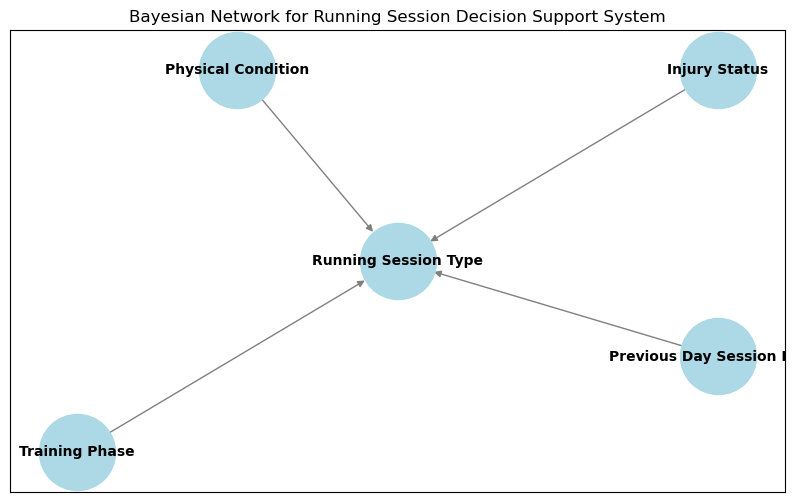

In [2]:
# code used below is based on examples and tutorials found here...
# https://networkx.org/documentation/stable/tutorial.html
# https://medium.com/swlh/a-tutorial-on-networkx-network-analysis-in-python-part-i-43c1d35830b6

# Define the structure of the Bayesian model
model = BayesianNetwork([
    ('Previous Day Session Effort', 'Running Session Type'),
    ('Injury Status', 'Running Session Type'),
    ('Physical Condition', 'Running Session Type'),
    ('Training Phase', 'Running Session Type')
])

# creates a directed graph from the model
nx_graph = nx.DiGraph()
nx_graph.add_edges_from(model.edges())

# sets the position for each node
pos = {
    'Running Session Type': (0.3, 0.5),  # central
    'Previous Day Session Effort': (0.4, 0.45),  # bottom right
    'Injury Status': (0.4, 0.6),  # top right
    'Physical Condition': (0.25, 0.6),  # top left
    'Training Phase': (0.2, 0.4)  # bottom left  
}

# sets the size of the figure
plt.figure(figsize=(10, 6))

# draw the graph
nx.draw_networkx(nx_graph, pos, arrows=True, with_labels=True, node_color='lightblue', 
                 edge_color='gray', node_size=3000, font_size=10, font_weight='bold')

# shows the plot
plt.title('Bayesian Network for Running Session Decision Support System')
plt.show()

### Creating the bayesian network

In [3]:
# creating the network
rsr_model = BayesianNetwork([
    ('Previous Day Session Effort', 'Running Session Type'),
    ('Injury Status', 'Running Session Type'),
    ('Physical Condition', 'Running Session Type'),
    ('Training Phase', 'Running Session Type')
    
])

# cpd for previous session
cpd_prev_session = TabularCPD(variable='Previous Day Session Effort', 
                              variable_card=3, 
                              values=[[0.7],[0.2],[0.1]],
                              state_names={'Previous Day Session Effort': ['Easy', 'Hard', 'Rest']}
                             )
# cpd for injury status
cpd_injury_status = TabularCPD(variable='Injury Status', 
                               variable_card=3,
                               values=[[0.85], [0.1], [0.05]],
                               state_names={'Injury Status': ['No Injury', 'Minor Injury', 'Injured']}            
                              )


# cpd for physical condition
cpd_physical_condition = TabularCPD(variable='Physical Condition',
                                    variable_card=3,
                                    values=[[0.5],[0.3],[0.2]],
                                    state_names={'Physical Condition': ['Good', 'Neutral', 'Poor']}
                                   )

# cpd for training phase
cpd_training_phase = TabularCPD(variable='Training Phase',
                                variable_card=4,
                                values=[[0.4],[0.3],[0.2],[0.1]],
                                state_names={'Training Phase': ['Base', 'Build', 'Peak', 'Taper']}
                               )


# reading these probabilities into a df from a spreadsheet of values
run_session_type_values = pd.read_excel('run_session_type_values.xlsx')

# creating list from the data frame
long_run_vals = run_session_type_values['long_run_vals'].values.tolist()
easy_run_vals = run_session_type_values['easy_run_vals'].values.tolist()
speed_run_vals = run_session_type_values['speed_run_vals'].values.tolist()
rest_vals = run_session_type_values['rest_vals'].values.tolist()

# using lists from above to create the cpd
# cpd for run session type
cpd_run_type = TabularCPD(variable='Running Session Type', variable_card=4,
                          values=[long_run_vals, # probabilities for long run
                                  easy_run_vals, # probabilities for easy run
                                  speed_run_vals,  # probabilities for speed run
                                  rest_vals],      # probabilities for rest day
                          
                          state_names={'Running Session Type': ['Long', 'Easy', 'Speed', 'Rest'],
                                       'Previous Day Session Effort': ['Easy', 'Hard', 'Rest'],
                                       'Injury Status': ['No Injury', 'Minor Injury', 'Injured'],
                                       'Physical Condition': ['Good', 'Neutral', 'Poor'],
                                       'Training Phase': ['Base', 'Build', 'Peak', 'Taper']},
                          
                          evidence=['Previous Day Session Effort',
                                    'Injury Status',
                                    'Physical Condition',
                                    'Training Phase'],
                          evidence_card=[3,3,3,4])

# adding parameters to the model
rsr_model.add_cpds(
    cpd_prev_session, cpd_injury_status, cpd_physical_condition, cpd_training_phase, cpd_run_type
)

### Validating the network model

I used some code from examples here to use for validation https://pgmpy.org/examples/Earthquake.html

#### Checking cpd's

In [4]:
# gets cpds input into model - checking they've all come through
rsr_model.get_cpds()

[<TabularCPD representing P(Previous Day Session Effort:3) at 0x7fbe25bdc910>,
 <TabularCPD representing P(Injury Status:3) at 0x7fbe25bdccd0>,
 <TabularCPD representing P(Physical Condition:3) at 0x7fbe25bdcca0>,
 <TabularCPD representing P(Training Phase:4) at 0x7fbe25bdcdc0>,
 <TabularCPD representing P(Running Session Type:4 | Previous Day Session Effort:3, Injury Status:3, Physical Condition:3, Training Phase:4) at 0x7fbe26781e20>]

In [5]:
print(cpd_prev_session)

+-----------------------------------+-----+
| Previous Day Session Effort(Easy) | 0.7 |
+-----------------------------------+-----+
| Previous Day Session Effort(Hard) | 0.2 |
+-----------------------------------+-----+
| Previous Day Session Effort(Rest) | 0.1 |
+-----------------------------------+-----+


In [6]:
print(cpd_injury_status)

+-----------------------------+------+
| Injury Status(No Injury)    | 0.85 |
+-----------------------------+------+
| Injury Status(Minor Injury) | 0.1  |
+-----------------------------+------+
| Injury Status(Injured)      | 0.05 |
+-----------------------------+------+


In [7]:
print(cpd_physical_condition)

+-----------------------------+-----+
| Physical Condition(Good)    | 0.5 |
+-----------------------------+-----+
| Physical Condition(Neutral) | 0.3 |
+-----------------------------+-----+
| Physical Condition(Poor)    | 0.2 |
+-----------------------------+-----+


In [8]:
print(cpd_training_phase)

+-----------------------+-----+
| Training Phase(Base)  | 0.4 |
+-----------------------+-----+
| Training Phase(Build) | 0.3 |
+-----------------------+-----+
| Training Phase(Peak)  | 0.2 |
+-----------------------+-----+
| Training Phase(Taper) | 0.1 |
+-----------------------+-----+


In [9]:
# checks cpd's are valid
rsr_model.check_model()

True

In [10]:
# checking nodes
rsr_model.nodes()

NodeView(('Previous Day Session Effort', 'Running Session Type', 'Injury Status', 'Physical Condition', 'Training Phase'))

In [11]:
# checking edges
rsr_model.edges()

OutEdgeView([('Previous Day Session Effort', 'Running Session Type'), ('Injury Status', 'Running Session Type'), ('Physical Condition', 'Running Session Type'), ('Training Phase', 'Running Session Type')])

In [12]:
# checking independencies
rsr_model.get_independencies()

(Physical Condition ⟂ Previous Day Session Effort, Training Phase, Injury Status)
(Physical Condition ⟂ Training Phase, Injury Status | Previous Day Session Effort)
(Physical Condition ⟂ Previous Day Session Effort, Injury Status | Training Phase)
(Physical Condition ⟂ Previous Day Session Effort, Training Phase | Injury Status)
(Physical Condition ⟂ Injury Status | Previous Day Session Effort, Training Phase)
(Physical Condition ⟂ Training Phase | Previous Day Session Effort, Injury Status)
(Physical Condition ⟂ Previous Day Session Effort | Training Phase, Injury Status)
(Previous Day Session Effort ⟂ Training Phase, Injury Status, Physical Condition)
(Previous Day Session Effort ⟂ Injury Status, Physical Condition | Training Phase)
(Previous Day Session Effort ⟂ Training Phase, Physical Condition | Injury Status)
(Previous Day Session Effort ⟂ Training Phase, Injury Status | Physical Condition)
(Previous Day Session Effort ⟂ Physical Condition | Training Phase, Injury Status)
(Previ

# Questions

In [13]:
# https://pgmpy.org/exact_infer/ve.html
rsr_infer = VariableElimination(rsr_model)

## Q1

An example using all of the nodes...

When in the peak training phase, feeling good but you've recently had a hard session and have a minor injury what running session is recommended?

Recommendation: Rest

In [14]:
q1 = rsr_infer.query(variables=['Running Session Type'], 
                     evidence={'Training Phase':'Base',
                               'Physical Condition':'Good',
                               'Injury Status': 'Minor Injury',
                               'Previous Day Session Effort': 'Hard'})

print(q1)

+-----------------------------+-----------------------------+
| Running Session Type        |   phi(Running Session Type) |
+=============================+=============================+
| Running Session Type(Long)  |                      0.2000 |
+-----------------------------+-----------------------------+
| Running Session Type(Easy)  |                      0.3500 |
+-----------------------------+-----------------------------+
| Running Session Type(Speed) |                      0.0500 |
+-----------------------------+-----------------------------+
| Running Session Type(Rest)  |                      0.4000 |
+-----------------------------+-----------------------------+


## Q2

Question uses partial information. Example of when not all information is available...

When the athlete has no injuries, feels physically good and is in the Build training phase. But previous session data is not available, what session is recommended?

Recommendation: Long

In [15]:
q2 = rsr_infer.query(variables=['Running Session Type'], 
                     evidence={'Injury Status': 'No Injury',
                               'Physical Condition': 'Good',
                               'Training Phase': 'Build'})
print(q2)

+-----------------------------+-----------------------------+
| Running Session Type        |   phi(Running Session Type) |
+=============================+=============================+
| Running Session Type(Long)  |                      0.3700 |
+-----------------------------+-----------------------------+
| Running Session Type(Easy)  |                      0.3420 |
+-----------------------------+-----------------------------+
| Running Session Type(Speed) |                      0.2100 |
+-----------------------------+-----------------------------+
| Running Session Type(Rest)  |                      0.0780 |
+-----------------------------+-----------------------------+


## Q3

This uses the child node to predict the likelihood of one of the parent nodes...

What is the most likely training phase an athlete is in given they have run a speed session and have a minor injury?

Most likely phase: Peak

In [16]:
# Querying the probable states of 'Training Phase' given 'Running Session Type' is 
# 'Speed' and injury status is 'Minor Injury'
q3 = rsr_infer.query(variables=['Training Phase'], 
                                                evidence={'Running Session Type': 'Speed',
                                                          'Injury Status': 'Minor Injury'})
print(q3)

+-----------------------+-----------------------+
| Training Phase        |   phi(Training Phase) |
+=======================+=======================+
| Training Phase(Base)  |                0.2908 |
+-----------------------+-----------------------+
| Training Phase(Build) |                0.3178 |
+-----------------------+-----------------------+
| Training Phase(Peak)  |                0.3498 |
+-----------------------+-----------------------+
| Training Phase(Taper) |                0.0415 |
+-----------------------+-----------------------+
